# AI-Powered Mobile Addiction Risk Prediction System

# 1. Business Problem

Smartphone addiction has become a major issue among students, employees, and teenagers.
Excessive mobile usage can negatively affect:

- Sleep quality
- Productivity
- Mental health
- Study performance
- Social interaction
- Physical health

Many users are unaware of how deeply mobile usage patterns affect their daily lives.

Companies in:
- Digital wellness
- Health technology
- Educational platforms
- Productivity applications

want to understand user behavior and predict risky mobile addiction patterns before they become severe.

---

# 2. Problem Statement

The goal of this project is to build a supervised Machine Learning Regression model that predicts:

## Daily Screen Time (in hours)

using behavioral and smartphone usage features such as:

- Number of notifications
- Social media usage
- Gaming time
- Sleep duration
- Number of installed apps
- Night-time usage
- Entertainment usage

The system will help identify users with high mobile dependency and provide behavioral insights.

---

# 3. Objective

The main objectives of this project are:

- Predict daily screen time accurately
- Analyze factors contributing to mobile addiction
- Identify high-risk users
- Understand behavioral patterns
- Build a scalable prediction system
- Provide data-driven digital wellness insights

---

# 4. Business Use Cases

This system can be used by:

| Industry | Use Case |
|---|---|
| HealthTech | Detect unhealthy mobile habits |
| EdTech | Track student productivity |
| Productivity Apps | Suggest focus improvements |
| Parents | Monitor child screen usage |
| Wellness Apps | Build digital detox recommendations |
| HR Analytics | Understand employee productivity patterns |

### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

### 2. Load Data

In [3]:
df = pd.read_csv('mobile_addiction_dataset.csv')

### 3. Preview Data

In [4]:
df.head()

,id,age,gender,app_usage_time,screen_on_time,number_of_apps_installed,battery_drain,data_usage,user_behavior_class,sleep_hours,notifications,social_media_usage,gaming_time,study_work_time,weekend_usage,weekday_usage,battery_cycles,device_age,internet_type,location_type
0,32824,49,Male,5.79,5.69,80.0,24.88,6.38,Moderate Usage,5.48,102,2.01,3.83,6.01,7.67,6.74,508,3.20,4G,Semi-Urban
1,16299,15,Male,6.14,4.95,92.0,16.63,5.43,High Usage,6.49,116,2.64,1.80,5.38,6.69,4.58,464,2.07,4G,Urban
2,28506,51,Male,4.96,7.21,67.0,22.11,5.62,High Usage,6.02,100,4.71,2.88,3.12,10.06,6.63,368,3.53,WiFi,Urban
3,6690,32,Other,5.27,6.20,71.0,24.81,5.93,High Usage,6.90,138,3.23,4.70,7.86,8.53,6.58,422,1.79,4G,Urban
4,26894,41,Male,7.71,5.02,71.0,21.61,6.58,Low Usage,7.44,87,2.59,1.96,6.18,5.38,4.14,616,1.83,4G,Urban


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        40000 non-null  int64  
 1   age                       40000 non-null  int64  
 2   gender                    40000 non-null  str    
 3   app_usage_time            40000 non-null  float64
 4   screen_on_time            40000 non-null  float64
 5   number_of_apps_installed  39200 non-null  float64
 6   battery_drain             40000 non-null  float64
 7   data_usage                40000 non-null  float64
 8   user_behavior_class       40000 non-null  str    
 9   sleep_hours               40000 non-null  float64
 10  notifications             40000 non-null  int64  
 11  social_media_usage        40000 non-null  float64
 12  gaming_time               39200 non-null  float64
 13  study_work_time           40000 non-null  float64
 14  weekend_usage    

In [6]:
df.describe()

,id,age,app_usage_time,screen_on_time,number_of_apps_installed,battery_drain,data_usage,sleep_hours,notifications,social_media_usage,gaming_time,study_work_time,weekend_usage,weekday_usage,battery_cycles,device_age
count,40000.00000,40000.000000,40000.000000,40000.000000,39200.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,39200.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,20000.50000,34.499100,5.571403,6.521604,76.067372,21.194821,5.987693,6.265856,105.515825,3.675235,2.767839,4.663433,8.318107,5.721370,487.062650,3.118542
std,11547.14972,11.490046,1.049647,0.890470,14.218256,3.883951,1.226103,0.820688,21.829857,0.831386,0.873858,1.472331,1.264508,1.129802,99.126381,0.792661
min,1.00000,15.000000,1.940000,2.990000,24.000000,7.150000,1.980000,4.000000,35.000000,0.990000,0.000000,1.000000,3.170000,1.220000,81.000000,0.300000
25%,10000.75000,25.000000,4.840000,5.920000,66.000000,18.520000,5.130000,5.730000,90.000000,3.090000,2.140000,3.660000,7.457500,4.960000,420.000000,2.580000
50%,20000.50000,34.000000,5.480000,6.510000,76.000000,21.040000,5.900000,6.300000,104.000000,3.600000,2.670000,4.690000,8.310000,5.710000,485.000000,3.090000
75%,30000.25000,44.000000,6.230000,7.120000,85.000000,23.730000,6.760000,6.830000,119.000000,4.180000,3.300000,5.660000,9.170000,6.480000,551.000000,3.630000
max,40000.00000,54.000000,10.000000,10.460000,143.000000,38.590000,11.760000,9.350000,204.000000,8.000000,7.000000,10.450000,13.650000,10.580000,900.000000,6.000000


In [7]:
df.isnull().sum()

id                            0
age                           0
gender                        0
app_usage_time                0
screen_on_time                0
number_of_apps_installed    800
battery_drain                 0
data_usage                    0
user_behavior_class           0
sleep_hours                   0
notifications                 0
social_media_usage            0
gaming_time                 800
study_work_time               0
weekend_usage                 0
weekday_usage                 0
battery_cycles                0
device_age                    0
internet_type                 0
location_type                 0
dtype: int64

Two Columns Have Null Values(number_of_apps_installed, data_usage)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        40000 non-null  int64  
 1   age                       40000 non-null  int64  
 2   gender                    40000 non-null  str    
 3   app_usage_time            40000 non-null  float64
 4   screen_on_time            40000 non-null  float64
 5   number_of_apps_installed  39200 non-null  float64
 6   battery_drain             40000 non-null  float64
 7   data_usage                40000 non-null  float64
 8   user_behavior_class       40000 non-null  str    
 9   sleep_hours               40000 non-null  float64
 10  notifications             40000 non-null  int64  
 11  social_media_usage        40000 non-null  float64
 12  gaming_time               39200 non-null  float64
 13  study_work_time           40000 non-null  float64
 14  weekend_usage    

### 4. Univariate Analysis

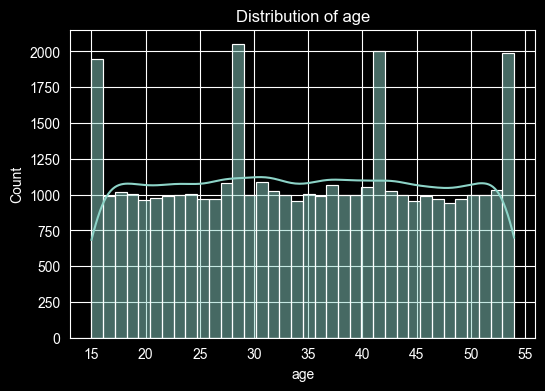

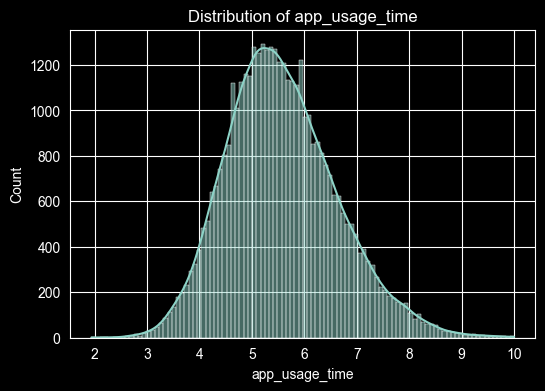

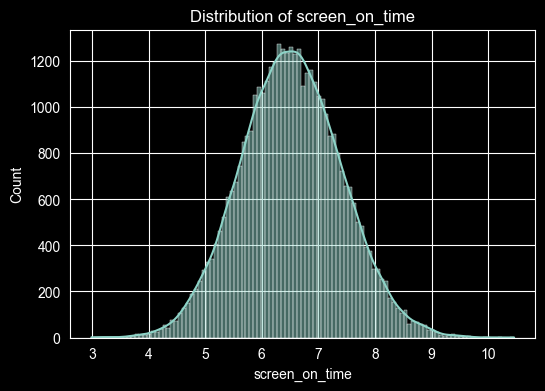

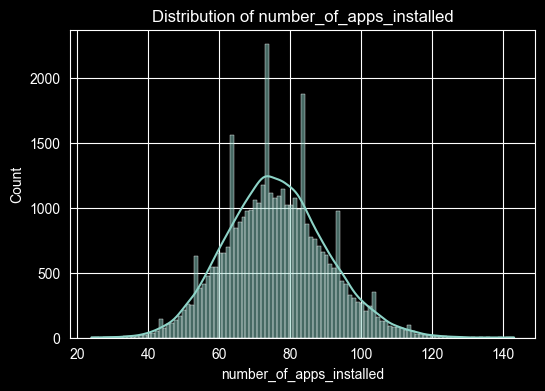

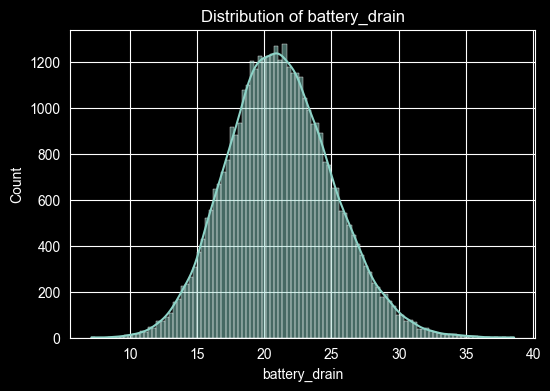

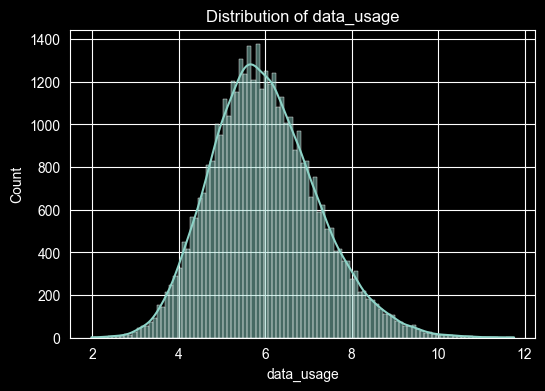

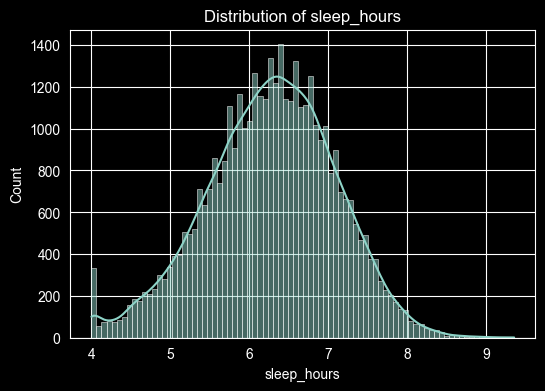

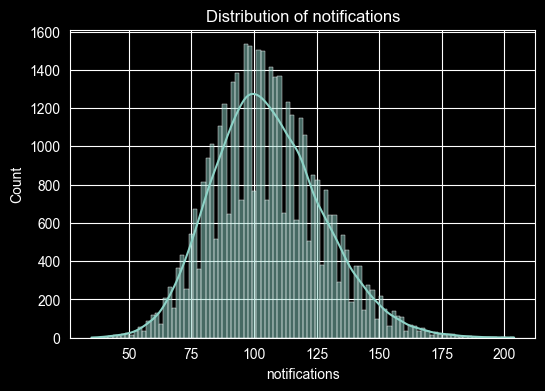

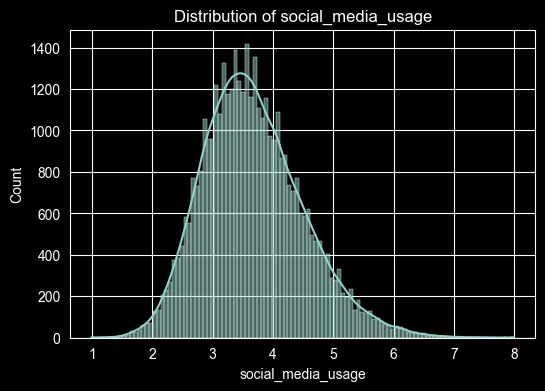

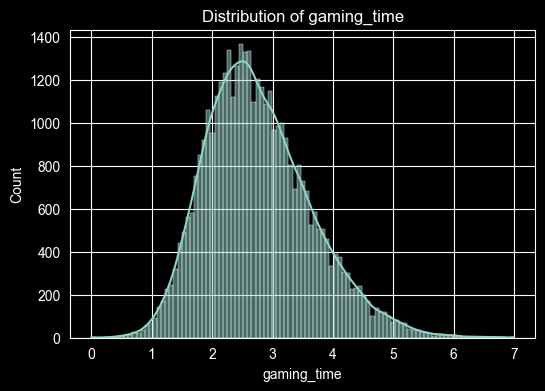

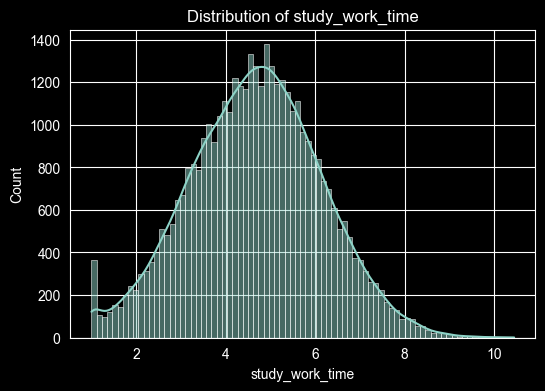

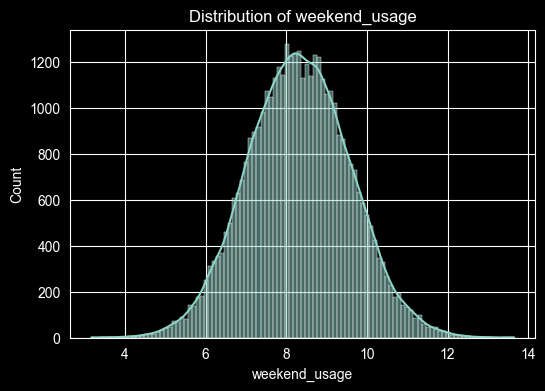

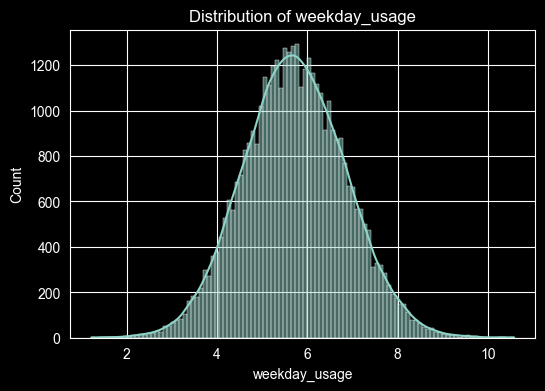

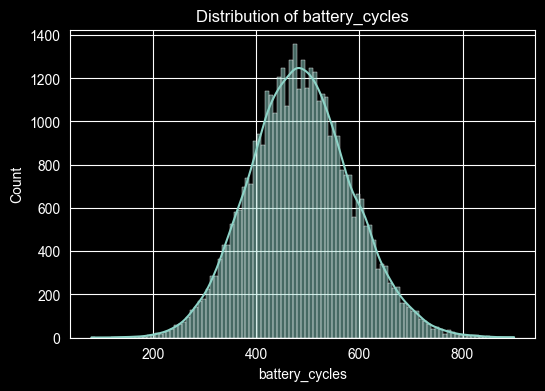

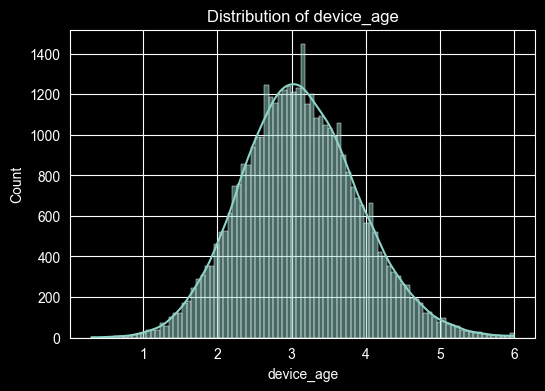

In [9]:
num_col = ['age', 'app_usage_time', 'screen_on_time', 'number_of_apps_installed', 'battery_drain', 'data_usage', 'sleep_hours',
           'notifications', 'social_media_usage', 'gaming_time', 'study_work_time', 'weekend_usage',
           'weekday_usage', 'battery_cycles', 'device_age']

for col in num_col:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        40000 non-null  int64  
 1   age                       40000 non-null  int64  
 2   gender                    40000 non-null  str    
 3   app_usage_time            40000 non-null  float64
 4   screen_on_time            40000 non-null  float64
 5   number_of_apps_installed  39200 non-null  float64
 6   battery_drain             40000 non-null  float64
 7   data_usage                40000 non-null  float64
 8   user_behavior_class       40000 non-null  str    
 9   sleep_hours               40000 non-null  float64
 10  notifications             40000 non-null  int64  
 11  social_media_usage        40000 non-null  float64
 12  gaming_time               39200 non-null  float64
 13  study_work_time           40000 non-null  float64
 14  weekend_usage    

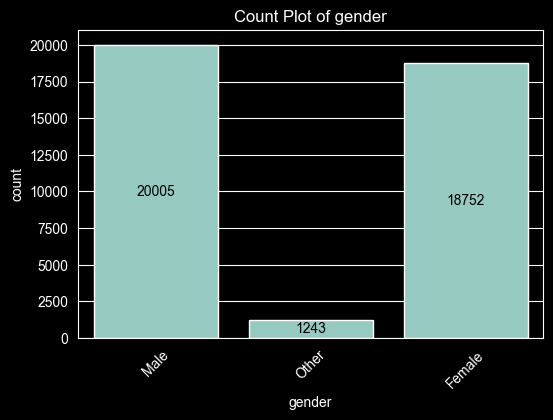

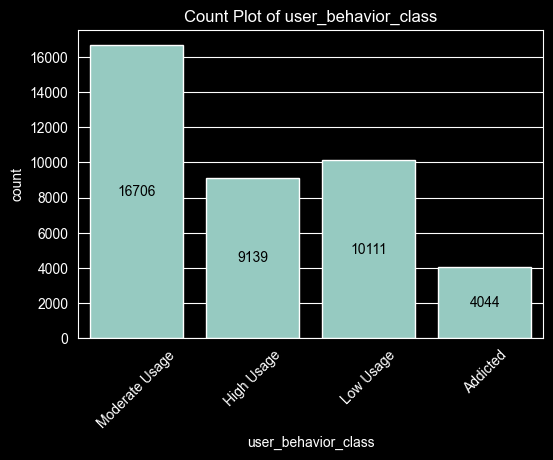

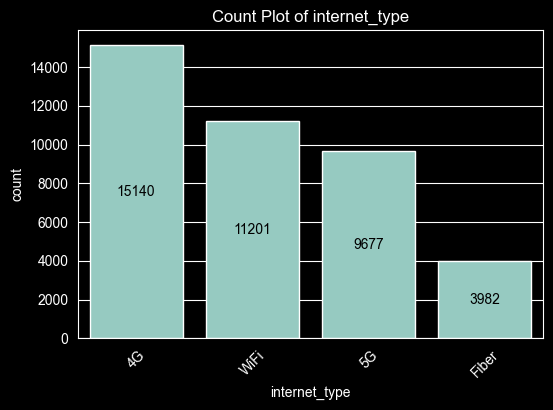

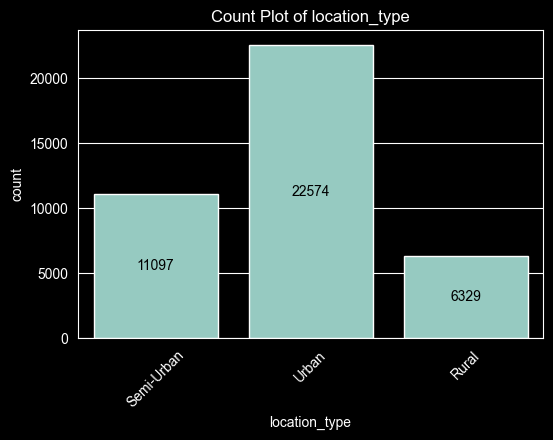

In [11]:
cat_col = ['gender', 'user_behavior_class', 'internet_type', 'location_type']

for col in cat_col:

    plt.figure(figsize=(6,4))

    ax = sns.countplot(x=col, data=df)

    for container in ax.containers:
        ax.bar_label(container, label_type='center', color='black')

    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45)

    plt.show()

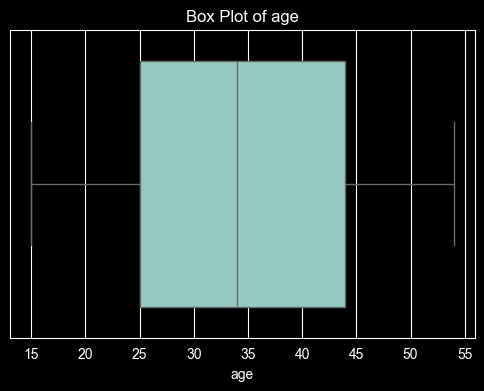

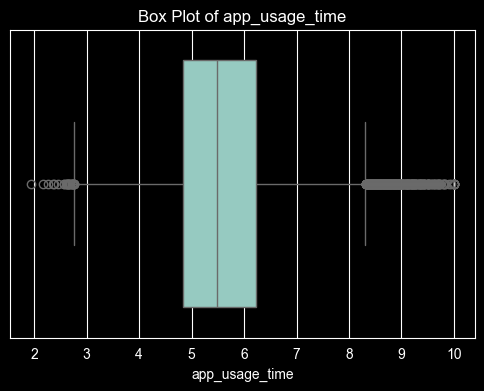

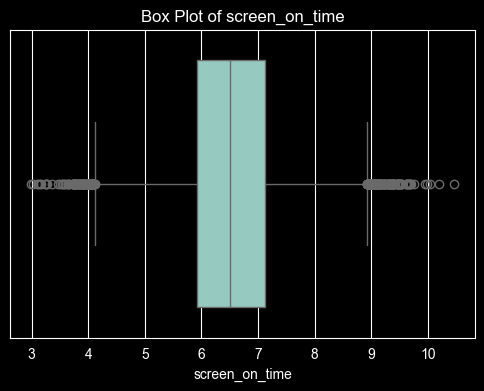

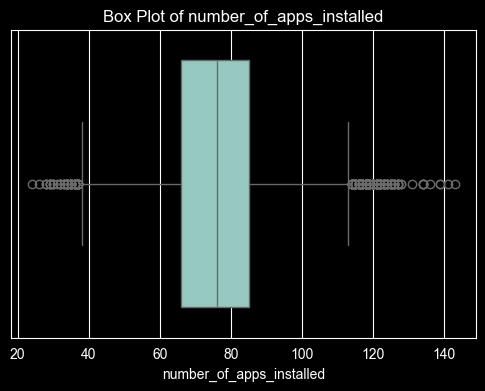

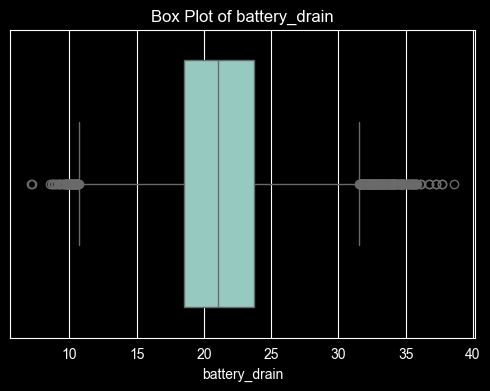

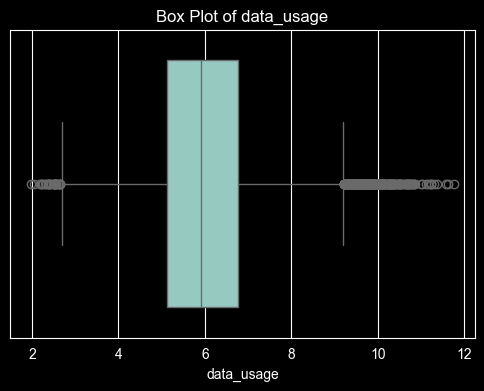

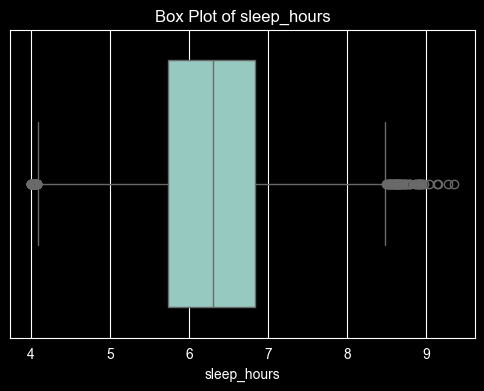

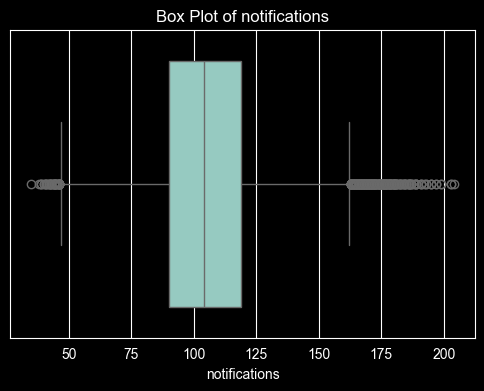

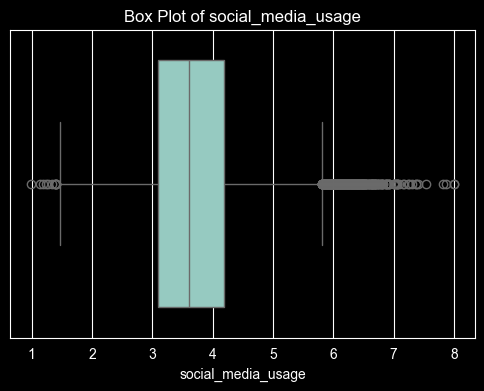

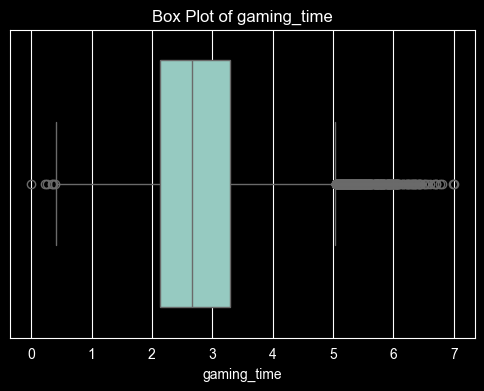

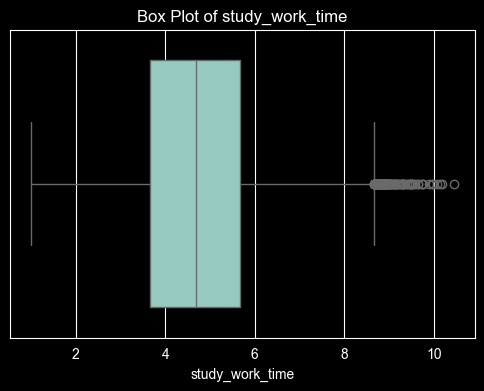

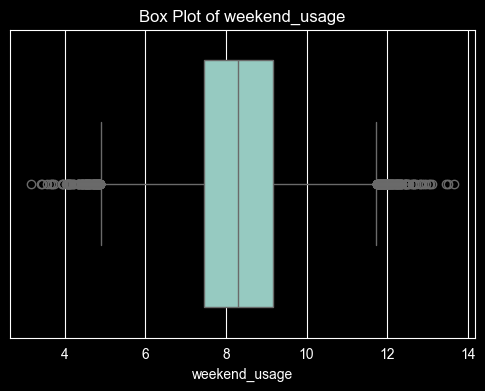

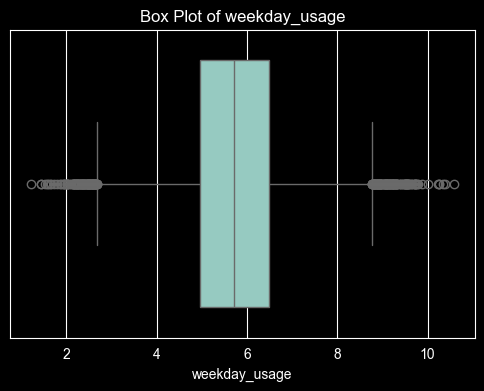

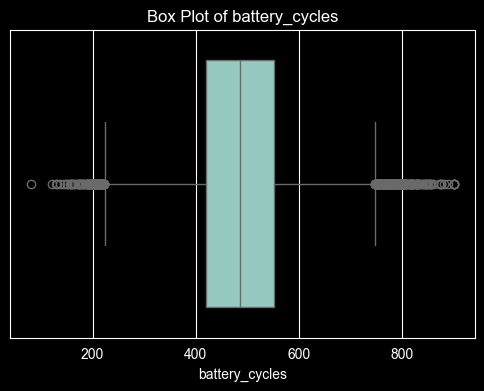

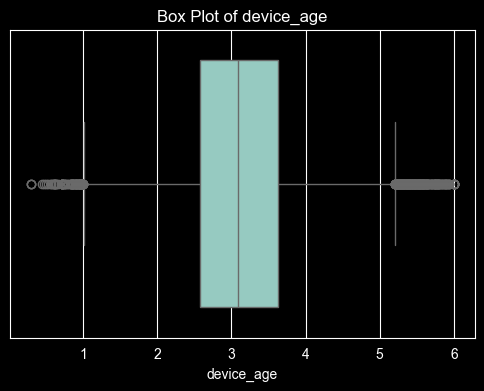

In [12]:
for col in num_col:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col])

    plt.title(f'Box Plot of {col}')

    plt.show()

| Column | Status  | Review |
|---|---------|---|
| age | Natural | 15–54 is perfectly normal |
| app_usage_time | Natural | Max 10 hrs/day is high but realistic for addicted users |
| screen_on_time | Natural | 10.46 hrs possible for heavy users |
| number_of_apps_installed | Natural | 143 apps is high but common nowadays |
| battery_drain | Natural | 38.59% drain is believable |
| data_usage | Natural | 11.76 GB/day is high but possible |
| sleep_hours | Natural | 4 hrs is low but realistic |
| notifications | Natural | 204 notifications/day is possible |
| social_media_usage | Natural | 8 hrs is extreme but believable |
| gaming_time | Natural | 7 hrs gaming/day is realistic |
| study_work_time | Natural | 10.45 hrs is still acceptable |
| weekend_usage | Natural | 13.65 hrs on weekends is believable |
| weekday_usage | Natural | 10.58 hrs possible |
| battery_cycles | Natural | 900 cycles is realistic for old phones |
| device_age | Natural | 6 years old device is fine |

In [13]:
df.columns

Index(['id', 'age', 'gender', 'app_usage_time', 'screen_on_time',
       'number_of_apps_installed', 'battery_drain', 'data_usage',
       'user_behavior_class', 'sleep_hours', 'notifications',
       'social_media_usage', 'gaming_time', 'study_work_time', 'weekend_usage',
       'weekday_usage', 'battery_cycles', 'device_age', 'internet_type',
       'location_type'],
      dtype='str')

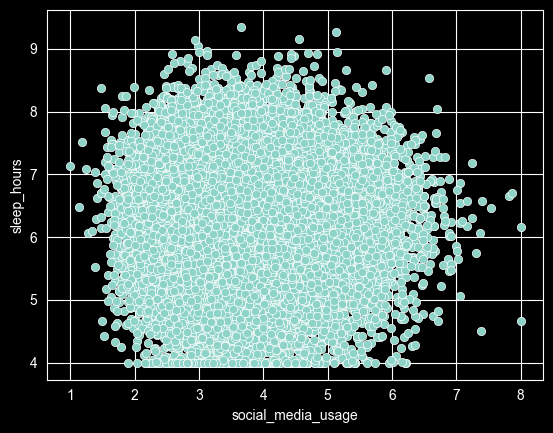

In [18]:
sns.scatterplot(x='social_media_usage', y='sleep_hours', data=df)
plt.show()

#### Key Insights
- Most users sleep between 5 to 8 hours
- Social media usage is concentrated between 2 to 6 hours
- Users with higher social media usage appear more likely to have lower sleep duration
- The relationship is not extremely strong, but a behavioral trend is visible
- The data distribution is dense, indicating many users follow similar usage patterns
- Reduced sleep quality

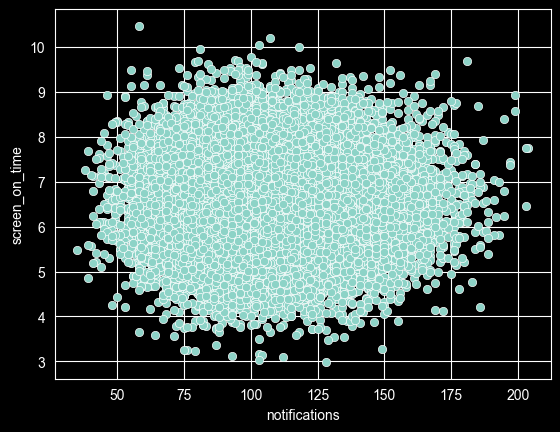

In [19]:
sns.scatterplot(x='notifications', y='screen_on_time', data=df)
plt.show()

#### Key Insights
- Most users receive around 70 to 160 notifications
- Screen-on time is mostly concentrated between 5 to 8 hours
- Users with higher notification counts generally show higher phone interaction
- Frequent notifications may trigger repeated phone checking behavior
- The relationship is visible but not extremely strong due to data spread

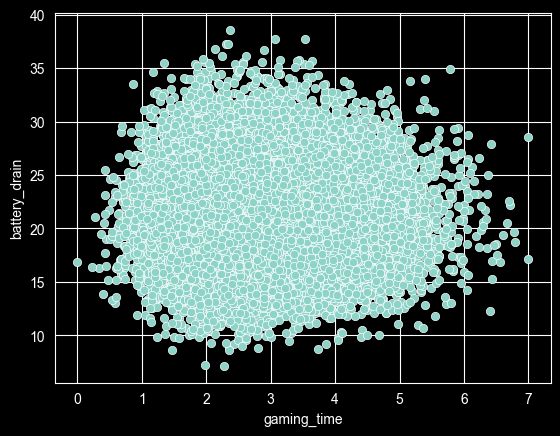

In [20]:
sns.scatterplot(x='gaming_time', y='battery_drain', data=df)
plt.show()

#### Key Insights
- Most users spend around 1 to 5 hours gaming
- Battery drain is mostly concentrated between 15% to 30%
- Higher gaming activity is associated with increased battery consumption
- Gaming appears to be one of the more power-intensive smartphone activities
- Some heavy gamers show extremely high battery drain values

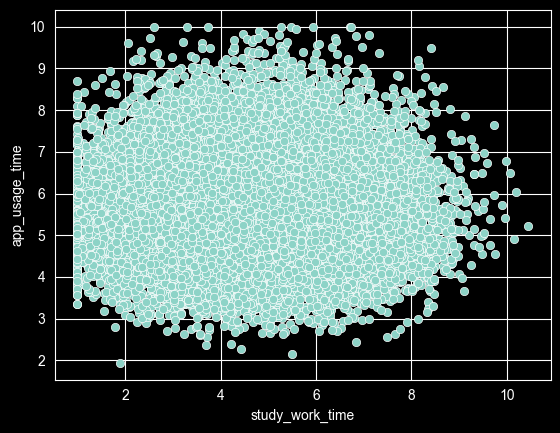

In [21]:
sns.scatterplot(x='study_work_time', y='app_usage_time', data=df)
plt.show()

#### Key Insights
- Most users spend around 2 to 8 hours on study/work activities
- App usage time is mainly concentrated between 3 to 8 hours
- Users with very high study/work time generally show relatively lower app usage
- Lower productivity hours are associated with wider variation in app usage behavior
- The relationship is not extremely strong, indicating multiple factors influence mobile usage

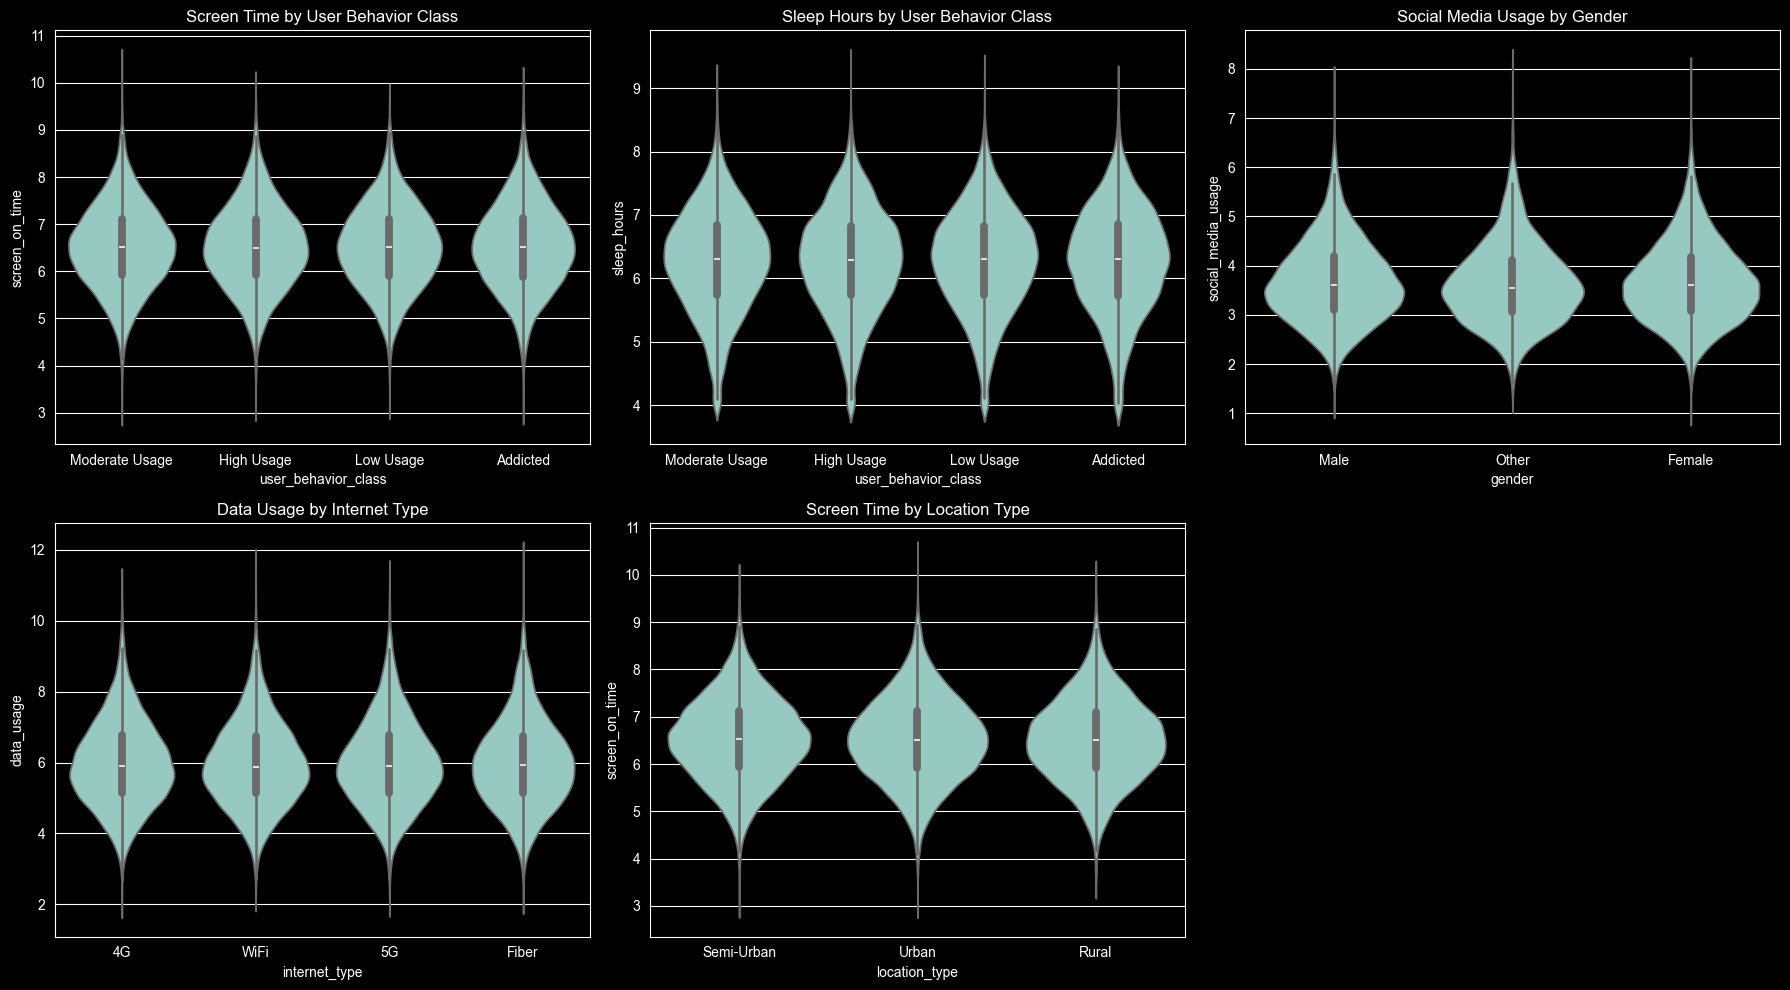

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.violinplot(
    x='user_behavior_class',
    y='screen_on_time',
    data=df,
    ax=axes[0,0]
)
axes[0,0].set_title('Screen Time by User Behavior Class')

sns.violinplot(
    x='user_behavior_class',
    y='sleep_hours',
    data=df,
    ax=axes[0,1]
)
axes[0,1].set_title('Sleep Hours by User Behavior Class')

sns.violinplot(
    x='gender',
    y='social_media_usage',
    data=df,
    ax=axes[0,2]
)
axes[0,2].set_title('Social Media Usage by Gender')

sns.violinplot(
    x='internet_type',
    y='data_usage',
    data=df,
    ax=axes[1,0]
)
axes[1,0].set_title('Data Usage by Internet Type')

sns.violinplot(
    x='location_type',
    y='screen_on_time',
    data=df,
    ax=axes[1,1]
)
axes[1,1].set_title('Screen Time by Location Type')

axes[1,2].axis('off')

plt.tight_layout()
plt.show()

# Violin Plot Analysis & Insights

---

# 1. Screen Time by User Behavior Class

## Insight
- Users across all behavior classes show screen-on time concentrated around **6 to 7 hours**
- The **Addicted** and **High Usage** groups display slightly wider distributions, indicating heavier and more inconsistent phone usage
- **Low Usage** users tend to have relatively more controlled screen behavior

## Business Insight
This suggests that users classified as addicted generally spend more active time on their devices, supporting the mobile addiction prediction objective.

---

# 2. Sleep Hours by User Behavior Class

## Insight
- Sleep duration is mostly concentrated between **5.5 to 7 hours**
- Addicted users show slightly lower median sleep hours
- Moderate and Low Usage users appear to maintain more balanced sleep patterns

## Behavioral Insight
Higher mobile dependency may contribute to reduced sleep duration and unhealthy digital habits.

## Business Use Cases
This insight can be valuable for:

- Wellness applications
- Sleep monitoring systems
- Digital detox recommendation platforms

---

# 3. Social Media Usage by Gender

## Insight
- Social media usage patterns are relatively similar across genders
- Female users appear to have a slightly wider distribution, indicating more variability in social media behavior
- Most users spend around **3 to 4 hours** on social platforms

## Behavioral Insight
Social media engagement remains consistently high across all gender groups, highlighting its strong influence on screen dependency behavior.

---

# 4. Data Usage by Internet Type

## Insight
- Users with **WiFi** and **Fiber** connections show slightly higher and wider data usage distributions
- **4G** users display comparatively moderate data consumption
- High-speed internet availability may encourage prolonged online activity and increased digital engagement

## Business Insight
Internet accessibility significantly influences mobile engagement and content consumption behavior.

---

# 5. Screen Time by Location Type

## Insight
- Urban users show slightly higher and more distributed screen-on time
- Rural and Semi-Urban users display relatively similar usage patterns
- Urban environments may contribute to increased smartphone dependency due to better internet accessibility and digitally connected lifestyles

## Behavioral Insight
Location-based lifestyle differences play an important role in influencing mobile usage behavior.

---

# Overall Conclusion

The violin plot analysis reveals noticeable behavioral differences across user categories. Users with high or addictive mobile usage patterns tend to exhibit:

- Longer screen-on durations
- Slightly reduced sleep hours
- Increased internet and data consumption

Additionally, factors such as internet accessibility and location type appear to influence smartphone engagement behavior, supporting the presence of digital dependency trends.

In [28]:
df['addiction_score'] = (
    df['social_media_usage'] +
    df['gaming_time'] +
    df['screen_on_time']
)

In [29]:
df['productivity_ratio'] = (
    df['study_work_time'] / df['app_usage_time']
)

In [31]:
df['notification_dependency'] = (
    df['notifications'] / df['screen_on_time']
)

In [32]:
df['weekend_addiction_ratio'] = (
    df['weekend_usage'] / df['weekday_usage']
)

In [33]:
df['data_per_hour'] = (
    df['data_usage'] / df['app_usage_time']
)

In [34]:
df['battery_drain_per_hour'] = (
    df['battery_drain'] / df['screen_on_time']
)

In [35]:
df['device_stress_score'] = (
    df['battery_cycles'] * df['battery_drain']
)

In [36]:
df['usage_intensity'] = (
    df['screen_on_time'] * df['number_of_apps_installed']
)

In [37]:
df['entertainment_dependency'] = (
    df['social_media_usage'] + df['gaming_time']
)

In [38]:
df['digital_wellness_score'] = (
    df['sleep_hours'] + df['study_work_time']
) - (
    df['screen_on_time'] + df['gaming_time']
)

In [39]:
df['high_usage_flag'] = (
    df['screen_on_time'] > 7
).astype(int)

In [41]:
df['heavy_gamer'] = (
    df['gaming_time'] > 4
).astype(int)

In [42]:
df.head()

,id,age,gender,app_usage_time,screen_on_time,number_of_apps_installed,battery_drain,data_usage,user_behavior_class,sleep_hours,...,notification_dependency,weekend_addiction_ratio,data_per_hour,battery_drain_per_hour,device_stress_score,usage_intensity,entertainment_dependency,digital_wellness_score,high_usage_flag,heavy_gamer
0,32824,49,Male,5.79,5.69,80.0,24.88,6.38,Moderate Usage,5.48,...,17.926186,1.137982,1.101900,4.372583,12639.04,455.20,5.84,1.97,0,0
1,16299,15,Male,6.14,4.95,92.0,16.63,5.43,High Usage,6.49,...,23.434343,1.460699,0.884365,3.359596,7716.32,455.40,4.44,5.12,0,0
2,28506,51,Male,4.96,7.21,67.0,22.11,5.62,High Usage,6.02,...,13.869626,1.517345,1.133065,3.066574,8136.48,483.07,7.59,-0.95,1,0
3,6690,32,Other,5.27,6.20,71.0,24.81,5.93,High Usage,6.90,...,22.258065,1.296353,1.125237,4.001613,10469.82,440.20,7.93,3.86,0,1
4,26894,41,Male,7.71,5.02,71.0,21.61,6.58,Low Usage,7.44,...,17.330677,1.299517,0.853437,4.304781,13311.76,356.42,4.55,6.64,0,0


In [43]:
df.isnull().sum()

id                            0
age                           0
gender                        0
app_usage_time                0
screen_on_time                0
number_of_apps_installed    800
battery_drain                 0
data_usage                    0
user_behavior_class           0
sleep_hours                   0
notifications                 0
social_media_usage            0
gaming_time                 800
study_work_time               0
weekend_usage                 0
weekday_usage                 0
battery_cycles                0
device_age                    0
internet_type                 0
location_type                 0
addiction_score             800
productivity_ratio            0
notification_dependency       0
weekend_addiction_ratio       0
data_per_hour                 0
battery_drain_per_hour        0
device_stress_score           0
usage_intensity             800
entertainment_dependency    800
digital_wellness_score      800
high_usage_flag               0
heavy_ga

In [44]:
df.to_csv('cleand.csv')